In [69]:
from google import genai
from dotenv import load_dotenv
import os
load_dotenv()
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
MODEL_NAME = "gemma-4-26b-a4b-it"

In [70]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict , Annotated
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langchain_core.messages import AnyMessage , HumanMessage 
from langgraph.graph.message import add_messages
from langchain.tools import tool
from langchain.messages import ToolMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [71]:
class AgentSchema(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    label : str

In [72]:
@tool
def check_balance(account_id: str) -> str:
    """Check the current account balance for a given account ID."""
    fake_balances = {"acc_101": 250.75, "acc_102": 0.00, "acc_103": -45.20}
    balance = fake_balances.get(account_id, 100.00)
    return f"Account {account_id} has a balance of ${balance:.2f}."


@tool
def restart_service(service_name: str) -> str:
    """Restart a given technical service by name."""
    valid_services = ["email", "database", "vpn", "printer"]
    if service_name.lower() in valid_services:
        return f"Service '{service_name}' has been successfully restarted."
    return f"Service '{service_name}' not recognized. Available services: {', '.join(valid_services)}."

In [73]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(
    model=MODEL_NAME
)

In [74]:
model = ChatGoogleGenerativeAI(model=MODEL_NAME)

billing_model = model.bind_tools([check_balance])
tech_model = model.bind_tools([restart_service])

In [75]:
def supervisor_node(state: AgentSchema) -> dict:
    last_msg = state['messages'][-1].content
    prompt = f"Read this message: '{last_msg}'. Reply with exactly one word: 'billing' or 'tech'."

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt)
    
    label = response.text.strip().lower()
    return {'label': label}

def billing_agent(state: AgentSchema) -> dict:
    response = billing_model.invoke(state['messages'])
    return {'messages' : [response]}

def tech_agent(state: AgentSchema) -> dict:
    response = tech_model.invoke(state['messages'])
    return { 'messages': [response]}

In [76]:
def route_to_specialist(state: AgentSchema) -> str:
    if state['label'] == 'billing':
        return 'billing'
    else :
        return 'tech'

In [77]:
billing_tools = ToolNode([check_balance])
tech_tools = ToolNode([restart_service])

In [78]:
graph = StateGraph(AgentSchema)
graph.add_node('supervisor_node', supervisor_node)
graph.add_node('billing_agent', billing_agent)
graph.add_node('tech_agent', tech_agent)
graph.add_node('billing_tools', billing_tools)
graph.add_node('tech_tools', tech_tools)

In [79]:
graph.add_edge(START, 'supervisor_node')

graph.add_conditional_edges(
    'supervisor_node',
    route_to_specialist,
    {
        'billing': 'billing_agent',
        'tech': 'tech_agent'
    }
)

graph.add_conditional_edges(
    'billing_agent',
    tools_condition,
    {
        'tools': 'billing_tools',
        '__end__': END
    }
)
graph.add_edge('billing_tools', 'billing_agent')

graph.add_conditional_edges(
    'tech_agent',
    tools_condition,
    {
        'tools': 'tech_tools',
        '__end__': END
    }
)
graph.add_edge('tech_tools', 'tech_agent')

agent = graph.compile()

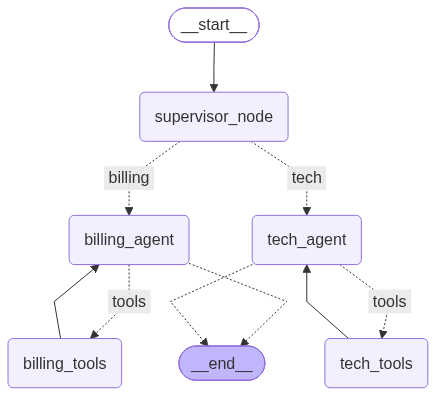

In [81]:
agent

In [80]:
result = agent.invoke({"messages": [HumanMessage(content="What's the balance on account acc_101?")]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's the balance on account acc_101?
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user is asking for the balance of a specific account, "acc_101".\nI should look for a tool that can check the balance of an account.\nThe `check_balance` tool seems appropriate for this task.\nIt requires an `account_id` as an argument.\nThe user has provided the `account_id` as "acc_101".\n\nTherefore, I should call `check_balance(account_id=\'acc_101\')`.'}]
Tool Calls:
  check_balance (call_577625)
 Call ID: call_577625
  Args:
    account_id: acc_101
================================= Tool Message =================================
Name: check_balance

Account acc_101 has a balance of $250.75.
================================== Ai Message ==================================

The balance on account acc_101 is $250.75.


In [82]:
result = agent.invoke({"messages": [HumanMessage(content="restart the database service")]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

restart the database service
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user wants to restart a service named "database". I should look for a tool that can restart services. The `restart_service` function seems appropriate for this task.\n\n1.  **Identify the tool**: `restart_service`\n2.  **Identify the argument**: `service_name="database"`\n3.  **Formulate the tool call**.'}]
Tool Calls:
  restart_service (call_524307)
 Call ID: call_524307
  Args:
    service_name: database
================================= Tool Message =================================
Name: restart_service

Service 'database' has been successfully restarted.
================================== Ai Message ==================================

OK. I've restarted the database service.


## Now with the help of create_agent()

In [85]:
from langchain.agents import create_agent

In [86]:
billing_agent = create_agent(model=model, tools=[check_balance])
tech_agent = create_agent(model=model, tools=[restart_service])

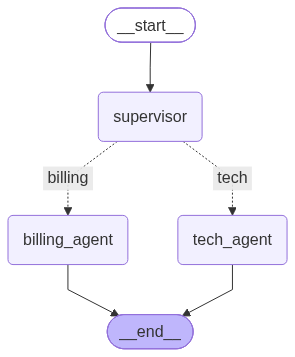

In [89]:
graph = StateGraph(AgentSchema)

graph.add_node('supervisor', supervisor_node)
graph.add_node('billing_agent', billing_agent)
graph.add_node('tech_agent', tech_agent)

graph.add_edge(START, 'supervisor')

graph.add_conditional_edges(
    'supervisor',
    route_to_specialist,
    {'billing': 'billing_agent', 'tech': 'tech_agent'}
)

graph.add_edge('billing_agent', END)
graph.add_edge('tech_agent', END)

agent = graph.compile()
agent

In [90]:
result = agent.invoke({"messages": [HumanMessage(content="What's the balance on account acc_101?")]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's the balance on account acc_101?
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user is asking for the balance of a specific account, `acc_101`. I should look for a tool that can check account balances. The `check_balance` tool seems appropriate for this task as it takes an `account_id` as an argument.\n\n1.  **Identify the tool**: `check_balance`\n2.  **Identify the argument**: `account_id = "acc_101"`\n3.  **Formulate the tool call**: `check_balance(account_id="acc_101")'}, {'type': 'thinking', 'thinking': '`'}]
Tool Calls:
  check_balance (call_398620)
 Call ID: call_398620
  Args:
    account_id: acc_101
================================= Tool Message =================================
Name: check_balance

Account acc_101 has a balance of $250.75.
================================== Ai Message ================================

In [91]:
result = agent.invoke({"messages": [HumanMessage(content="restart the database service")]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

restart the database service
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user wants to restart the "database service". I should check the available tools to see if there\'s a function for restarting services. I see `restart_service` which takes a `service_name`. I need to determine the exact name of the database service. Since the user just said "the database service", I don\'t have the specific name. However, in a typical environment, it might be `postgresql`, `mysql`, `mongodb`, etc. But I shouldn\'t guess. Wait, looking at the tool definition, it\'s a generic tool. I will try to restart a service named "database" or ask for clarification, but often in these scenarios, "database" might be the name or I should look for a way to list services. Since I can\'t list services, I\'ll try to call `restart_service` with `service_name=\'